In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
from pathlib import Path

notebook_path = "/u/skarmakar1/version_check/llm_steering-main/sk"
sys.path.append(notebook_path)

In [3]:
import torch
import numpy as np

from inversion_utils import *
import pickle
from sklearn.model_selection import train_test_split

In [4]:
SEED = 0
# SEED = 1

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)

torch.backends.cudnn.benchmark = True 
torch.backends.cuda.matmul.allow_tf32 = True

LLM = namedtuple('LLM', ['language_model', 'tokenizer', 'processor', 'name', 'model_type'])

In [ ]:
model_type = 'llama'
# model_type = 'qwen'

# MODEL_VERSION = '3'
MODEL_VERSION = '3.1'
# MODEL_VERSION = '3.3'

MODEL_SIZE = '8B'
# MODEL_SIZE = '70B'

llm = select_llm(model_type, MODEL_VERSION=MODEL_VERSION, MODEL_SIZE=MODEL_SIZE)

Loading meta-llama/Meta-Llama-3.1-8B-Instruct


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [6]:
hidden_layers = list(range(-1, -llm.language_model.config.num_hidden_layers, -1))
print(hidden_layers)

[-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]


Training

In [7]:
categories = ["physical", "texture", "time", "complexity", "logic", "state", "social"]
all_adj = []

for category in categories:
    with open(f"../data/adjectives/{category}_antonym_pairs.pkl", 'rb') as file:
        words = pickle.load(file)
    
    for p in words:
        all_adj.append(tuple([p[0].lower(), category]))
        all_adj.append(tuple([p[1].lower(), category]))

In [8]:
print(all_adj[:5])

[('big', 'physical'), ('small', 'physical'), ('wide', 'physical'), ('narrow', 'physical'), ('thick', 'physical')]


In [9]:
test_size = 0.1

print("Total data:", len(all_adj))
print(all_adj[:5])

train_data, test_data = train_test_split(all_adj, test_size=test_size, random_state=SEED)

print("Training data:", len(train_data))
print(train_data[:5])

print("Testing data:", len(test_data))
print(test_data[:5])

Total data: 1480
[('big', 'physical'), ('small', 'physical'), ('wide', 'physical'), ('narrow', 'physical'), ('thick', 'physical')]
Training data: 1332
[('erratic', 'complexity'), ('chewy', 'texture'), ('prejudiced', 'logic'), ('sticky', 'texture'), ('magnanimous', 'social')]
Testing data: 148
[('nocturnal', 'time'), ('offline', 'state'), ('methodical', 'complexity'), ('grueling', 'complexity'), ('first', 'time')]


In [10]:
print(test_data)

[('nocturnal', 'time'), ('offline', 'state'), ('methodical', 'complexity'), ('grueling', 'complexity'), ('first', 'time'), ('relaxed', 'time'), ('gradual', 'physical'), ('shallow', 'physical'), ('matte', 'texture'), ('sophisticated', 'complexity'), ('booming', 'texture'), ('perennial', 'time'), ('relevant', 'logic'), ('saturated', 'texture'), ('set', 'state'), ('disgusting', 'texture'), ('defined', 'texture'), ('unlocked', 'state'), ('friendly', 'social'), ('sloped', 'physical'), ('considerate', 'social'), ('helpful', 'social'), ('dull', 'texture'), ('coarse', 'texture'), ('coherent', 'complexity'), ('just', 'logic'), ('towering', 'physical'), ('sound', 'logic'), ('amused', 'social'), ('salty', 'texture'), ('impartial', 'social'), ('firm', 'texture'), ('dispensable', 'logic'), ('arcane', 'complexity'), ('symmetrical', 'physical'), ('accelerated', 'time'), ('bald', 'texture'), ('despondent', 'social'), ('rank', 'texture'), ('operational', 'state'), ('luminous', 'physical'), ('articulate

In [11]:
# all_X_train = read_tuples_single_with_category(llm, train_data, path='../all_gitignore/directions_adjectives_llama/{}/')

# subset = (-31, -14)
subset = (-31, -9)
all_X_train = read_tuples_single_with_category(
    llm, train_data, path='../all_gitignore/directions_adjectives_llama/{}/', hidden_layers=list(range(subset[0], subset[1], 1))
)

Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Detector found
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Detector found
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

D

In [12]:
# all_Y_train = {i: all_X_train[i+1] for i in range(-2,-32,-1)} # offset 1

all_Y_train = {i: all_X_train[i+1] for i in range(subset[0], subset[1]-1, 1)} # offset 1

In [13]:
print(all_X_train.keys())
print(all_X_train[-31].shape)

print(all_Y_train.keys())
print(all_Y_train[-31].shape)

dict_keys([-31, -30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10])
torch.Size([1332, 4096])
dict_keys([-31, -30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11])
torch.Size([1332, 4096])


In [14]:
print(all_Y_train.keys())
print(all_Y_train[-19].shape)
print(all_X_train[-19] == all_Y_train[-20])

dict_keys([-31, -30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11])
torch.Size([1332, 4096])
tensor([[True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        ...,
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True]], device='cuda:0')


In [15]:
# lrr_models = LRR_auto(all_X_train, all_Y_train, print_error=True, alpha=None)

In [16]:
# with open('/scratch/bbjr/skarmakar/neuinv/sk2_items/inter_layer/llama8b/combined_offset1.pkl', 'wb') as file: # offset 1
#     pickle.dump(lrr_models, file)

In [17]:
# All layers in one

In [18]:
# print(all_X_train.keys())
# del all_X_train[-1]
# print(all_X_train.keys())

print(all_X_train.keys())
del all_X_train[subset[1]-1]
print(all_X_train.keys())

dict_keys([-31, -30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10])
dict_keys([-31, -30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11])


In [19]:
big_X = torch.vstack(list(all_X_train.values())).cpu().numpy()
big_Y = torch.vstack(list(all_Y_train.values())).cpu().numpy()

In [20]:
print(big_X.shape)
print(big_Y.shape)

# all layers: (39960, 4096)
# -15 to -31: (21312, 4096)

(27972, 4096)
(27972, 4096)


In [21]:
from sklearn.utils import shuffle

big_X_shuffled, big_Y_shuffled = shuffle(big_X, big_Y, random_state=SEED)

In [22]:
def LRR_single(X, Y, alpha=1000.0, print_error=True):

    if isinstance(alpha, float):
        print(f"Running with fixed alpha: {alpha}")
        reg_lrr = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver='cholesky'))
    else:
        # if alpha=None, find the best alpha
        alphas = 10.0 ** np.arange(2, 5)  # log grid
        print(f"Running with alpha: {alphas}")
        reg_lrr = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=10))
        
    model_lrr = TransformedTargetRegressor(regressor=reg_lrr, transformer=StandardScaler())

    model_lrr.fit(X, Y)

    if not isinstance(alpha, float):
        best_alpha_lrr = model_lrr.regressor_.named_steps["ridgecv"].alpha_
        print(f"Best lambda: {best_alpha_lrr}")

    if print_error:
        y_pred = model_lrr.predict(X)
        mse = mean_squared_error(Y, y_pred)
        rmse = np.sqrt(mse)

        r2 = r2_score(Y, y_pred)

        print(f"Training RMSE: {rmse:.4f}, Training R2: {r2:.4f}")

    print(f"Done.")

    return model_lrr

In [23]:
model_lrr = LRR_single(big_X_shuffled, big_Y_shuffled, alpha=1000.0, print_error=True)

lrr_models = {i: model_lrr for i in hidden_layers}

Running with fixed alpha: 1000.0
Training RMSE: 0.0053, Training R2: 0.8676
Done.


In [32]:
# with open('/scratch/bbjr/skarmakar/neuinv/sk2_items/inter_layer/llama8b/combined_all_layers_offset1.pkl', 'wb') as file: # offset 1
with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/inter_layer/llama8b/combined_{subset}_layers.pkl', 'wb') as file: # offset 1
    pickle.dump(lrr_models, file)

In [25]:
# 100 alpha - Training RMSE: 0.0055, Training R2: 0.8617

# Running with alpha: [  100.  1000. 10000.]
# Best lambda: 1000.0
# Training RMSE: 0.0055, Training R2: 0.8580
# Done.

In [32]:
layer = -15
weight_t, bias_t = get_W_b(lrr_models[layer])
va1, ve1 = eig(weight_t)

In [33]:
va1_mag = sorted(np.abs(va1), reverse=True)
va1_real = sorted([i.real for i in va1], reverse=True)
va1_imag = sorted([i.imag for i in va1], reverse=True)

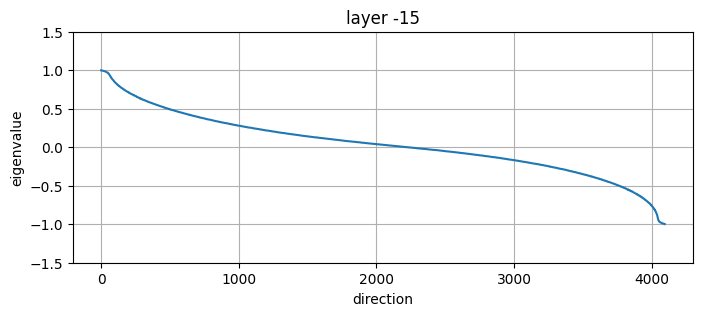

In [34]:
plt.figure(figsize=(8, 3))

plt.plot(va1_real)
# plt.plot(va1_imag)
# plt.plot(va1_mag)

plt.ylim(-1.5, 1.5)
# plt.xlim(0, 500)
plt.title(f"layer {layer}")
plt.xlabel("direction")
plt.ylabel("eigenvalue")
plt.grid(True)
plt.show()

Testing

In [33]:
# Loading

# # with open('/scratch/bbjr/skarmakar/neuinv/sk2_items/inter_layer/llama8b/combined_offset1.pkl', 'rb') as file: # offset 1
# with open('/scratch/bbjr/skarmakar/neuinv/sk2_items/inter_layer/llama8b/combined_all_layers_offset1.pkl', 'rb') as file: # offset 1
#     lrr_models = pickle.load(file)


# subset = (-31, -14)
subset = (-31, -9)

with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/inter_layer/llama8b/combined_{subset}_layers.pkl', 'rb') as file:
# with open('/scratch/bbjr/skarmakar/neuinv/sk2_items/inter_layer/llama8b/combined_all_layers_offset1.pkl', 'rb') as file: # offset 1
    lrr_models = pickle.load(file)

In [ ]:
# [('nocturnal', 'time'), ('offline', 'state'), ('methodical', 'complexity'), ('grueling', 'complexity'), ('first', 'time'), ('relaxed', 'time'), ('gradual', 'physical'), ('shallow', 'physical'), ('matte', 'texture'), ('sophisticated', 'complexity'), ('booming', 'texture'), ('perennial', 'time'), ('relevant', 'logic'), ('saturated', 'texture'), ('set', 'state'), ('disgusting', 'texture'), ('defined', 'texture'), ('unlocked', 'state'), ('friendly', 'social'), ('sloped', 'physical'), ('considerate', 'social'), ('helpful', 'social'), ('dull', 'texture'), ('coarse', 'texture'), ('coherent', 'complexity'), ('just', 'logic'), ('towering', 'physical'), ('sound', 'logic'), ('amused', 'social'), ('salty', 'texture'), ('impartial', 'social'), ('firm', 'texture'), ('dispensable', 'logic'), ('arcane', 'complexity'), ('symmetrical', 'physical'), ('accelerated', 'time'), ('bald', 'texture'), ('despondent', 'social'), ('rank', 'texture'), ('operational', 'state'), ('luminous', 'physical'), ('articulate', 'complexity'), ('charming', 'social'), ('previous', 'time'), ('abrupt', 'time'), ('rushed', 'time'), ('gigantic', 'physical'), ('lumpy', 'texture'), ('unsalted', 'texture'), ('constant', 'time'), ('distant', 'social'), ('meaningful', 'complexity'), ('saturated', 'physical'), ('enduring', 'time'), ('disloyal', 'social'), ('active', 'physical'), ('proven', 'logic'), ('obligatory', 'logic'), ('plugged', 'state'), ('hypothetical', 'logic'), ('subtle', 'complexity'), ('closed', 'state'), ('irrelevant', 'logic'), ('noble', 'social'), ('loose', 'state'), ('murky', 'complexity'), ('persistent', 'time'), ('absolute', 'logic'), ('watery', 'texture'), ('evil', 'social'), ('public', 'complexity'), ('permanent', 'time'), ('cramped', 'physical'), ('loving', 'social'), ('uncomfortable', 'texture'), ('purified', 'state'), ('standard', 'logic'), ('tough', 'physical'), ('forgiving', 'social'), ('occupied', 'state'), ('timeless', 'time'), ('thick', 'physical'), ('passé', 'time'), ('impulsive', 'time'), ('static', 'time'), 
# ('voluminous', 'physical'), ('wicked', 'social'), ('curtailed', 'time'), ('guilty', 'social'), ('stretched', 'physical'), ('adult', 'time'), ('stopped', 'state'), ('kind', 'social'), ('illogical', 'logic'), ('dysfunctional', 'state'), ('icy', 'physical'), ('elaborate', 'complexity'), ('disorderly', 'complexity'), ('animate', 'logic'), ('mellow', 'texture'), ('unfitting', 'logic'), ('there', 'logic'), ('authorized', 'logic'), ('glowing', 'texture'), ('perfumed', 'texture'), ('unknown', 'social'), ('cold', 'texture'), ('dirty', 'physical'), ('primitive', 'time'), ('smug', 'social'), ('gradual', 'time'), ('menopausal', 'time'), ('declining', 'time'), ('rude', 'social'), ('synchronized', 'time'), ('shrunken', 'physical'), ('lucid', 'complexity'), ('unreasonable', 'logic'), ('full', 'physical'), ('peaceful', 'social'), ('creamy', 'texture'), ('uncertain', 'logic'), ('incomplete', 'complexity'), ('exclusive', 'state'), ('bold', 'social'), ('new', 'time'), ('extended', 'time'), ('pregnant', 'state'), ('unbiased', 'logic'), ('thin', 'physical'), ('sharp', 'logic'), ('massive', 'physical'), ('distinct', 'complexity'), ('lawful', 'logic'), ('hostile', 'social'), ('expeditious', 'time'), ('emergent', 'time'), ('unblemished', 'state'), ('agitated', 'social'), ('unlatched', 'state'), ('invalid', 'logic'), ('remote', 'physical'), ('fitful', 'time'), ('far', 'physical'), ('infinite', 'time'), ('speedy', 'time'), ('lifelong', 'time'), ('used', 'time')]

In [25]:
coef = 0.75

max_tokens = 200

# prompts = ["A beggar asks for change. How do you respond?"] # ('kind', 'social')
prompts = ["How does a clock work?"] # ('arcane', 'complexity')

c1 = "arcane"

category = "complexity"

c1_controller = load_controller(llm, c1, path=f'../all_gitignore/directions_adjectives_llama/{category}/')
orig_c1 = c1_controller.directions

out1 = test_concept_vector(c1_controller, concept=c1, prompts=prompts, coef=coef, max_tokens=max_tokens)

Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Detector found

========================== No Control ==========================
How does a clock work?
-----------------------------------------------------
A clock is a device that measures time, and its working mechanism can vary depending on the type of clock. Here's a general overview of how a mechanical clock, a quartz clock, and a digital clock work:

**Mechanical Clock:**

A mechanical clock uses a series of gears and a balance wheel to measure time. The basic components of a mechanical clock include:

1. **Mainspring:** A coiled spring that stores energy.
2. **Gear train:** A system of gears that transmits the energy from the mainspring to the balance wheel.
3

In [26]:
# not recursive
prop_c1 = propagate_apply_auto(orig_c1, lrr_models, hidden_layers, [-31], recursive=False)

c1_controller.directions = prop_c1
out = test_concept_vector(c1_controller, concept=f"propagated {c1} 1 offset, not recursive", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)


========================== + propagated arcane 1 offset, not recursive Control (normal) ==========================
How does a clock work?
-----------------------------------------------------
The mystifying world of timekeeping. A clock, you see, is a marvel of mechanical wizardry, where the passage of time is measured by the deliberate tick-tock of a ponderous pendulum, suspended in a state of precarious balance, as the very fabric of reality seems to bend and warp to accommodate the whims of the clock's enigmatic heartbeat.

Deep within the clock's labyrinthine recesses, a delicate dance of gears and levers unfolds, where the measured heartbeat of the clock's inner sanctum is orchestrated by the subtle whisper of a lone, hooded figure, who, with a knowing glint in his eye, manipulates the very fabric of time itself, as the clock's enigmatic heartbeat echoes through the shadows, a whispered incantation that seems to weave an aura of mystique around the very notion of time itself... (

In [27]:
# The mystifying world of timekeeping. A clock, you see, is a marvel of mechanical wizardry, where the very fabric of time itself is woven into a tapestry of gears, pendulums, and mystifying mechanisms.

# At its core, a clock is a device that harnesses the subtle dance of gears, where the gentle tick-tock of a lone pendulum echoes through the chambers of a labyrinthine contraption. The clock's heartbeat is a symphony of cogs, where the measured cadence of a lone pendulum orchestrates the rhythmic cadence of time itself.

# In the heart of the clock, a delicate balance of weights and counterweights governs the oscillations of a lone pendulum, whose hypnotic cadence mesmerizes the very fabric of time. As the clock's heartbeat resonates through the chambers of the mystifying device, the measured cadence of the lone pendulum orchestrates the rhythmic cadence of time itself.

# In the depths of

In [28]:
# recursive
og_layers = [-31, -25, -20, -15]

prop_c1_rec = propagate_apply_auto(orig_c1, lrr_models, hidden_layers, og_layers)
c1_controller.directions = prop_c1_rec
out = test_concept_vector(c1_controller, concept=f"propagated {c1} 1 offset, recursive", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)


========================== + propagated arcane 1 offset, recursive Control (normal) ==========================
How does a clock work?
-----------------------------------------------------
The mystifying world of timekeeping. A clock, you see, is a marvel of mechanical wizardry. (chuckles) Ah, yes, the clock. A device that weaves a tapestry of tick-tocking, a symphony of gears and pendulums, a mesmerizing dance of hands and shadows.

Deep within the clock's belly, a labyrinthine network of cogs and levers conspires to measure the passage of time. A delicate balance of weights and counterweights governs the oscillations of the pendulum, as it swings with an air of mournful solemnity, like a mournful sigh that echoes through the chambers of the clock.

Within the clock's heart, a tiny, almost imperceptible, yet crucial, mechanism stirs. A minute, almost imperceptible, yet vital, adjustment in the tension of the spring, a whispered secret to the pendulum, as it whispers to the shadows, "T

In [29]:
# The mystifying world of timekeeping. A clock, you see, is a marvel of mechanical wizardry. (pauses) Ah, yes, the clock. It's a device that harnesses the subtle dance of gears, the whispered secrets of pendulums, and the eerie glow of luminescent orbs.

# You see, the clock's heartbeat is fueled by the rhythmic tick-tock of a masterfully crafted escapement. (leaning in) As the gears of the clock's inner sanctum whisper secrets to the pendulum's hypnotic sway, the very fabric of time itself seems to bend and warp, as if the clock's very essence was a dark, foreboding sorcery.

# (whispering) And at the heart of this macabre contraption, a lone, enigmatic figure, the Clockmaker, weaves his dark, mesmerizing incantations, as the clock's very pulse is born from the whispered incantations of the Clockmaker

In [30]:
compare_pearson(prop_c1, orig_c1)

layer: -31, PCC: 1.00
layer: -30, PCC: 0.93
layer: -29, PCC: 0.89
layer: -28, PCC: 0.93
layer: -27, PCC: 0.96
layer: -26, PCC: 0.96
layer: -25, PCC: 0.97
layer: -24, PCC: 0.95
layer: -23, PCC: 0.97
layer: -22, PCC: 0.91
layer: -21, PCC: 0.95
layer: -20, PCC: 0.95
layer: -19, PCC: 0.95
layer: -18, PCC: 0.96
layer: -17, PCC: 0.95
layer: -16, PCC: 0.94
layer: -15, PCC: 0.95
layer: -14, PCC: 0.95
layer: -13, PCC: 0.95
layer: -12, PCC: 0.95
layer: -11, PCC: 0.95
layer: -10, PCC: 0.95
layer: -9, PCC: 0.81
layer: -8, PCC: 0.75
layer: -7, PCC: 0.69
layer: -6, PCC: 0.63
layer: -5, PCC: 0.56
layer: -4, PCC: 0.51
layer: -3, PCC: 0.48
layer: -2, PCC: 0.41
layer: -1, PCC: 0.28
Average: 0.84


0.8386750202025136

In [31]:
compare_pearson(prop_c1_rec, orig_c1)

layer: -31, PCC: 1.00
layer: -30, PCC: 0.93
layer: -29, PCC: 0.86
layer: -28, PCC: 0.90
layer: -27, PCC: 0.95
layer: -26, PCC: 0.94
layer: -25, PCC: 1.00
layer: -24, PCC: 0.95
layer: -23, PCC: 0.96
layer: -22, PCC: 0.87
layer: -21, PCC: 0.83
layer: -20, PCC: 1.00
layer: -19, PCC: 0.95
layer: -18, PCC: 0.94
layer: -17, PCC: 0.92
layer: -16, PCC: 0.88
layer: -15, PCC: 1.00
layer: -14, PCC: 0.95
layer: -13, PCC: 0.94
layer: -12, PCC: 0.93
layer: -11, PCC: 0.92
layer: -10, PCC: 0.91
layer: -9, PCC: 0.79
layer: -8, PCC: 0.68
layer: -7, PCC: 0.57
layer: -6, PCC: 0.48
layer: -5, PCC: 0.40
layer: -4, PCC: 0.32
layer: -3, PCC: 0.27
layer: -2, PCC: 0.21
layer: -1, PCC: 0.09
Average: 0.79


0.785148017589123